In [1]:
!pip install qutip.qip
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 47.6 MB/s eta 0:00:00


# Nova seção

In [2]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import seaborn as sns
from tqdm import tqdm
from scipy.linalg import expm, sinm, cosm
from qutip import Qobj, tensor, identity, qeye, ket2dm,ptrace
from qutip_qip.operations import *

#Mutual information

In [3]:
def Rxs(theta_a,theta_b):
    return tensor(rx(theta_a),qeye(16),rx(theta_b))

def cnots():
    cnot1=tensor(cnot(3,0,1),cnot(3,1,2))
    cnot2=tensor(cnot(3,0,2),cnot(3,2,0))
    return cnot2*cnot1

def rhoarhob(epsilon_b,beta_a=1, epsilon_a=1, beta_b=2):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a)/Z_a,np.exp(-beta_b*epsilon_b)/Z_b,1/(Z_a*Z_b)

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa * (1-pb)
    element_22 = alpha**2 +pb*(1-pa)
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return qt.Qobj(matrix,dims=[[2,2],[2,2]])
def rho(e, b,ea=1,ba=1):
    # Definindo a matriz identidade 2x2
    idtt= np.eye(2)

    # Definindo as matrizes Pauli
    sy = np.array([[0, -1j], [1j, 0]])
    sz=np.array([[1, 0], [0, -1]])
    # Constantes

    bb=b*ba
    eb=e*ea
    # Hamiltoniana do sistema
    H_A = -0.5 * ea * sz
    H_B = -0.5 * eb * sz

    # Função partição
    Za = np.trace(expm(-ba * H_A))

    Zb = np.trace(expm(-bb * H_B))

    #correlação
    a = 1/(Za*Zb)

    qmp=qt.tensor(qt.sigmam(),qt.sigmap())
    qpm=qt.tensor(qt.sigmap(),qt.sigmam())
    #operador densidade

    chiab=a*qpm.full()+np.conjugate(a)*qmp.full()

    return qt.Qobj(np.kron(expm(-ba * H_A)/Za,expm(-bb * H_B)/Zb)+chiab,dims=[[2,2],[2,2]])

def thetas(e,b,ea=1,ba=1):
  #parametro de correlação
  #parametros do sistema
  ea=1
  ba=1
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea*0.5)/Za

  p_b=np.exp(-bb*eb*0.5)/Zb

  #coeficiente

  a=1/(Za*Zb)

  theta_a=2*np.arctan(p_a)
  theta_b=2*np.arctan(p_b)

  return theta_a,theta_b

def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  ea=1
  ba=1
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb

  #coeficiente

  a=1/(Za*Zb)**1.5

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=abs(p_b-p_a)/(pp-pm)*0.5+0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pm))
  theta_b=2*np.arccos(np.sqrt(pp))

  return theta_a,theta_b,x

def entropy(rho):
    return qt.entropy_vn(rho)


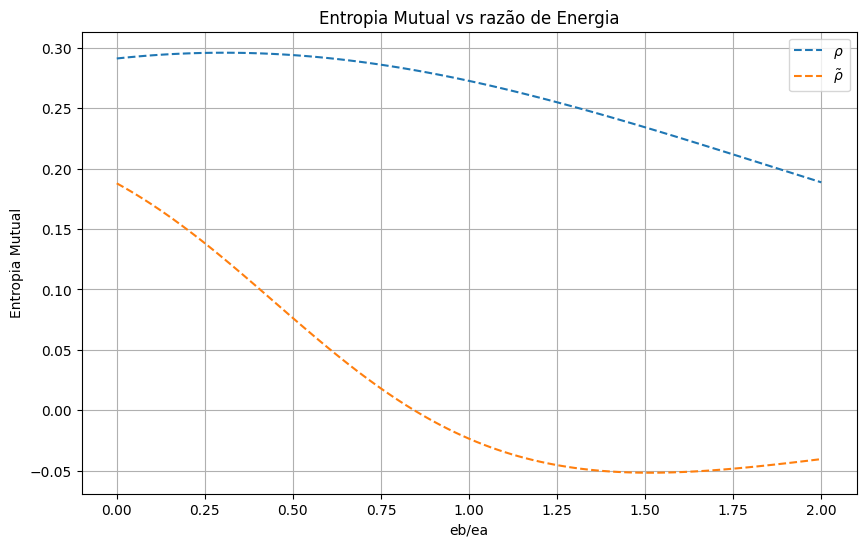

In [8]:
ener=np.linspace(0,2,101)
#listas
entropies1=np.zeros(len(ener))
entropies2=np.zeros(len(ener))
entropies3=np.zeros(len(ener))
entropies4=np.zeros(len(ener))
#calculo da entropia
for i,e in enumerate(ener):
  entropies2[i]=qt.entropy_mutual(rho(e,1),0,1)
  entropies4[i]=qt.entropy_mutual(Qobj(rhoarhob(e,2),dims=[[2,2],[2,2]]),0,1)
# Plotando o gráfico
plt.figure(figsize=(10, 6))
#plt.plot(ener, entropies1, '--', label='$\\rho_{A}$')
plt.plot(ener, entropies2, '--', label='$\\rho$')
#plt.plot(ener, entropies3, '--', label='$\\tilde{\\rho}_{A}$')
plt.plot(ener, entropies4, '--', label='$\\tilde{\\rho}$')
plt.xlabel('eb/ea')
plt.ylabel('Entropia Mutual')
plt.title('Entropia Mutual vs razão de Energia')
plt.legend()
plt.grid(True)
plt.show()


#Trabalho em função da temperatura e energia

In [6]:
def thetas_u(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea/2)/Za
  p_b=np.exp(-bb*eb/2)/Zb
  #coeficiente

  pm=0.5*(p_a+p_b+abs(p_b-p_a))

  pp=0.5*(p_a+p_b-abs(p_b-p_a))

  x=0 # é escrito como x=((pb-pa)/(pb-pa)+1)/2=1, já que o alpha = 0 evita problema computacional

  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x
def control_target(control,target,num_bits,U):
  # Define projectors for the control qubit
  P0 = qt.basis(2, 0) * qt.basis(2, 0).dag()  # Projector onto the |0> state
  P1 = qt.basis(2, 1) * qt.basis(2, 1).dag()  # Projector onto the |1> state
  #criando qobj
  C0 =qt.Qobj(1)
  C1 =qt.Qobj(1)
  #criando gate com controle e alvo
  for i in range(num_bits):
    #criando operação no alvo
    if target==i:

      C0=tensor(C0,qeye(2))
      C1=tensor(C1,U)
    #escolhendo o controle
    elif control==i:

      C0=tensor(C0,P0)
      C1=tensor(C1,P1)

    else:

      C0=tensor(C0,qeye(2))
      C1=tensor(C1,qeye(2))
  return np.array((C0+C1).full())

def u_plus(x):
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 + term2
    return u_minus


def u_minus(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return u_minus
def cnot_gate(control, target, num_qubits):
    return np.array(cnot(N=num_qubits,control=control, target=target).full())

def cnots_n(n_qubits):
    #gerando o tamanho dos dois cnots
    inteiro=int(n_qubits/2)
    cn_quan=Qobj(qeye(2**n_qubits),dims=(cnot(n_qubits,0,1).dims))
    #gerando cnot generalizado
    for i in range(1,inteiro):

      flag=tensor(cnot(inteiro,0,i),cnot(inteiro,inteiro-1,inteiro-(i+1)))
      cn_quan=cn_quan*flag
    return cn_quan

def box_correlation(num_qubits,control,target,x):

    circuit =cnot_gate(control, target, num_qubits)@control_target(target,control,num_qubits,u_minus(x))@cnot_gate(control, target, num_qubits)

    return circuit

def box_par_swap(num_qubits,control,target,x):

    circuit =cnot_gate(control, target, num_qubits)@control_target(target,control,num_qubits,u_plus(x))@cnot_gate(control, target, num_qubits)

    return circuit
def boxs_correlation(num_qubits,x):
    #gerando a matriz identidade para gerar os circuitos
    result=Qobj(qeye(2**num_qubits),dims=(cnot(num_qubits,0,3).dims))
    inteiro=int(num_qubits/2)
    #multiplicando as portas lógicas
    for i in range(inteiro):
      result=result*Qobj(box_correlation(num_qubits,(inteiro-(i+1)),(inteiro+i),x),dims=(cnot(num_qubits,0,1).dims))
    return result

def boxs_par_swap(num_qubits):
    #gerando a matriz identidade para gerar os circuitos
    result=Qobj(qeye(2**num_qubits),dims=(cnot(num_qubits,0,1).dims))
    inteiro=int(num_qubits/2)
    #multiplicando as portas lógicas
    for i in range(inteiro):
      result=Qobj(box_par_swap(num_qubits,(inteiro-(i+1)),(inteiro+i),0.6),dims=(cnot(num_qubits,0,1).dims))*result
    return result

def hamiltoniana(eb,ea=1,num_qubits=4):
  #gerando a matriz identidade para gerar os circuitos
  resultfi=Qobj(qeye(2**(num_qubits-2)),dims=(cnot(num_qubits-2,0,1).dims))
  inteiro=int((num_qubits)/2)
  #gerando o hamiltoniano
  for i in range(1,num_qubits-1):
    result1=Qobj(1)
    result2=Qobj(1)
    for j in range(1,num_qubits-1):
      if i==j and i<inteiro:
        result1=tensor(result1,-ea*qt.sigmaz()/2)
        result2=tensor(result2,qeye(2))
      elif i==j and i>=inteiro:
        result2=tensor(result2,-eb*qt.sigmaz()/2)
        result1=tensor(result1,qeye(2))
      else:
        result1=tensor(result1,qeye(2))
        result2=tensor(result2,qeye(2))
    resultfi=resultfi+Qobj(result1+result2,dims=cnot(num_qubits-2,0,1).dims)
  return resultfi

#hamiltoniana para calcular calor A
def hamiltoniana_a(eb,ea=1,num_qubits=4):
  #gerando a matriz identidade para gerar os circuitos
  if int((num_qubits-2)/2)>1:
    resultfi=Qobj(qeye(2**(int((num_qubits-2)/2))),dims=(cnot(int((num_qubits-2)/2),0,1).dims))
  else:
    return -ea*qt.sigmaz()/2
  inteiro=int((num_qubits)/2)
  #gerando o hamiltoniano
  for i in range(1,int((num_qubits-2)/2+1)):
    result1=Qobj(1)
    result2=Qobj(1)
    for j in range(1,int((num_qubits)/2)+1):
      if i==j and i<inteiro:
        result1=tensor(result1,-ea*qt.sigmaz()/2)
        result2=tensor(result2,qeye(2))
      else:
        result1=tensor(result1,qeye(2))
        result2=tensor(result2,qeye(2))
    resultfi=resultfi+Qobj(result1+result2,dims=cnot(int((num_qubits-2)/2),0,1).dims)
  return resultfi

def Rxs(theta_a,theta_b,N):
    #gerando portas de rotação que representarão um estado termico
    return Qobj(tensor(rx(theta_a),qeye(2**(N-2)),rx(theta_b)),dims=cnot(N,0,1).dims)

def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea/2)/Za
  p_b=np.exp(-bb*eb/2)/Zb
  #coeficiente

  a=1/(Za*Zb)**1.5

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=((p_b-p_a)/(pp-pm)+1)*0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x


/usr/local/lib/python3.11/dist-packages/matplotlib/contour.py:1371: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/usr/local/lib/python3.11/dist-packages/matplotlib/contour.py:1372: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/usr/local/lib/python3.11/dist-packages/numpy/ma/core.py:2820: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


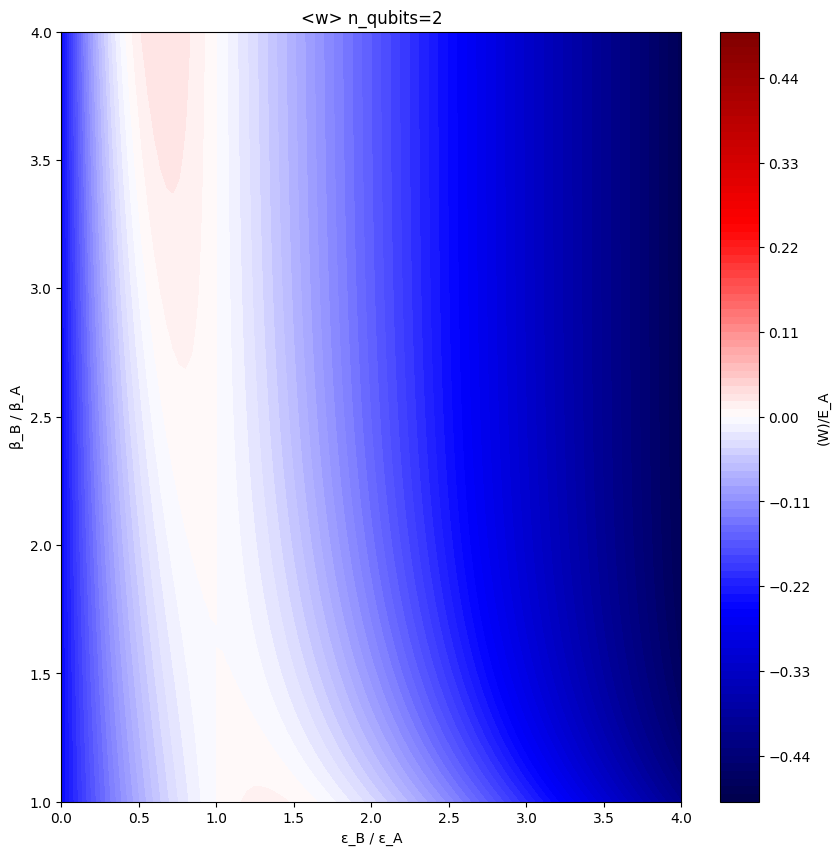

In [10]:
#gerando matrizes
ener=np.linspace(0,4,101)
beta=np.linspace(1,4,101)

X,Y=np.meshgrid(ener,beta)#mesh

for fig,i in enumerate(range(4,5,2)):
  #gerando as matrizes
  w_mean=np.zeros((len(ener),len(ener)),dtype=complex)
  box1=cnots_n(i)
  box2=boxs_par_swap(i)
  #gerando o estado inicial
  dimension=cnot(i,0,1).dims
  rho0_f=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
  trace_ind=np.linspace(1,i-2,i-2,dtype=int)
  for k,b in enumerate(beta):
    for j,e in enumerate(ener):

      #gerando estado inicial
      rho0=rho0_f

      # gerando estado
      theta_a,theta_b,x=thetas_c(e,b)
      rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

      #calculando rho final
      rho0=rho_therma_corr1*rho_therma_corr1.dag()
      rho_therma_corr1=box2*rho_therma_corr1
      rhof=rho_therma_corr1*rho_therma_corr1.dag()

      #calculo do trabalho
      w=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())
      w_mean[k][j]=w.real

  #plotando o gráfico
  levels=np.linspace(-0.5,0.5,101)
  plt.figure(figsize=(10, 10))
  plt.title(f"<w> n_qubits={i-2}")
  plt.contourf(X, Y, w_mean,levels, cmap='seismic')
  plt.colorbar(label='(W)/E_A')
  plt.xlabel('ε_B / ε_A')
  plt.ylabel('β_B / β_A')
  plt.show()

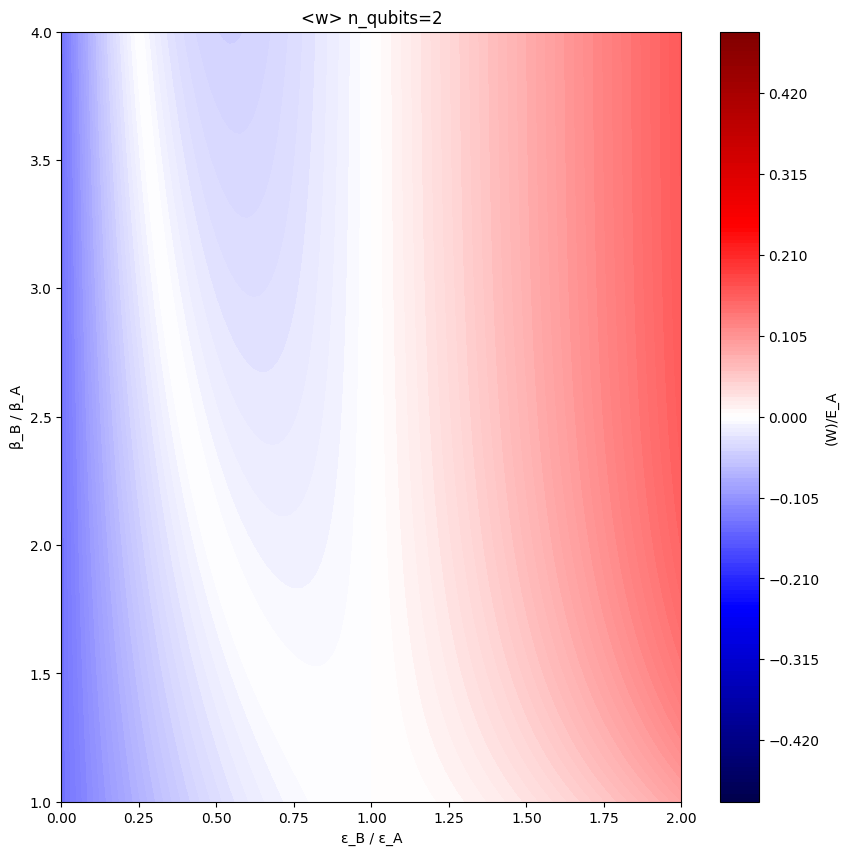

In [11]:
#gerando matrizes
ener=np.linspace(0,2,101)
beta=np.linspace(1,4,101)

X,Y=np.meshgrid(ener,beta)#mesh

for fig,i in enumerate(range(4,5,2)):
  #gerando as matrizes
  w_mean=np.zeros((len(ener),len(ener)),dtype=complex)
  box1=cnots_n(i)
  box2=boxs_par_swap(i)
  trace_ind=np.linspace(1,i-2,i-2,dtype=int)
  dimension=cnot(i,0,1).dims
  rho0_f=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])

  for k,b in enumerate(beta):
    for j,e in enumerate(ener):

      #gerando o estado inicial
      rho0=rho0_f

      # gerando estado
      theta_a,theta_b,x=thetas_u(e,b)
      rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

      #calculando rho final
      rho0=rho_therma_corr1*rho_therma_corr1.dag()
      rho_therma_corr1=box2*rho_therma_corr1
      rhof=rho_therma_corr1*rho_therma_corr1.dag()

      #calculo do trabalho
      w=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())
      w_mean[k][j]=w.real

  #plotando o gráfico
  levels=np.linspace(-0.5,0.5,201)
  plt.figure(figsize=(10, 10))
  plt.title(f"<w> n_qubits={i-2}")
  plt.contourf(X, Y, w_mean,levels, cmap='seismic')
  plt.colorbar(label='(W)/E_A')
  plt.xlabel('ε_B / ε_A')
  plt.ylabel('β_B / β_A')
  plt.show()

# Calor A

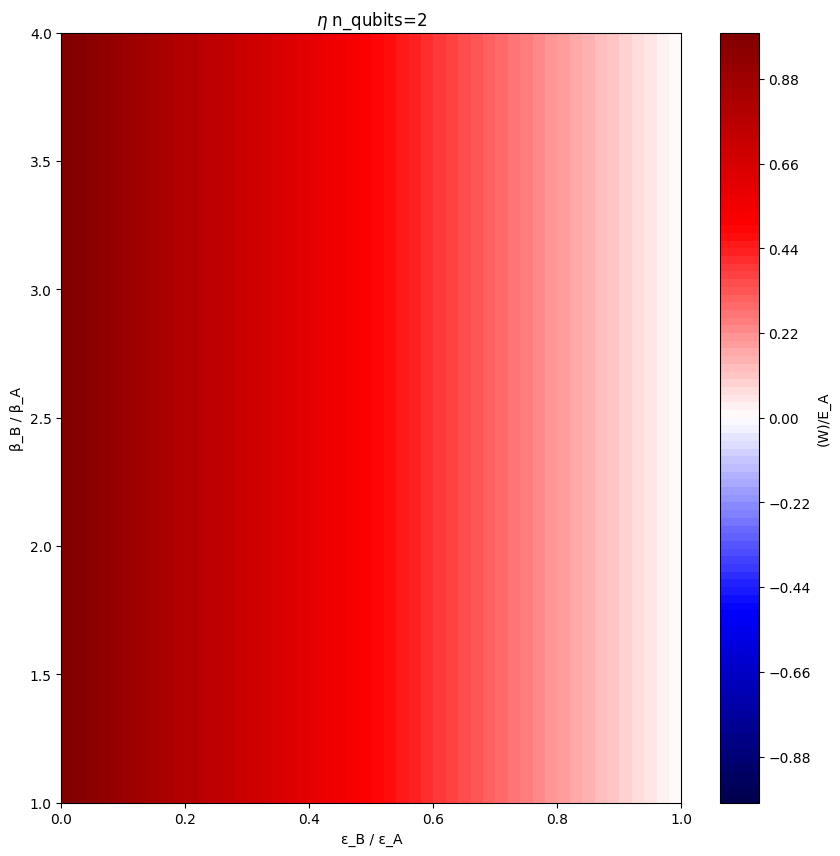

In [12]:
#gerando matrizes
ener=np.linspace(0,1,101)
beta=np.linspace(1,4,101)

X,Y=np.meshgrid(ener,beta)#mesh

for fig,i in enumerate(range(4,5,2)):
  #gerando as matrizes
  eta_mean=np.zeros((len(ener),len(ener)),dtype=complex)
  box1=cnots_n(i)
  box2=boxs_par_swap(i)
  #gerando o estado inicial
  trace_ind=np.linspace(1,i-2,i-2,dtype=int)
  trace_ind_q=np.linspace(1,int((i-2)/2),int((i-2)/2),dtype=int)
  dimension=cnot(i,0,1).dims
  rho0_f=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
  for k,b in enumerate(beta):
    for j,e in enumerate(ener):

      #gerando estado inicial
      rho0=rho0_f

      # gerando estado
      theta_a,theta_b,x=thetas_c(e,b)


      rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

      #calculando rho final
      rho0=rho_therma_corr1*rho_therma_corr1.dag()
      rho_therma_corr1=box2*rho_therma_corr1
      rhof=rho_therma_corr1*rho_therma_corr1.dag()

      #calculo do trabalho
      qa=-(((ptrace(rhof,trace_ind_q)-ptrace(rho0,trace_ind_q))*hamiltoniana_a(e,1,i)).tr())
      w=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())
      eta_mean[k][j]=-(w/qa).real

  #plotando o gráfico
  levels=np.linspace(-1,1,101)
  plt.figure(figsize=(10, 10))
  plt.title(f"$\\eta$ n_qubits={i-2}")
  plt.contourf(X, Y, eta_mean,levels, cmap='seismic')
  plt.colorbar(label='(W)/E_A')
  plt.xlabel('ε_B / ε_A')
  plt.ylabel('β_B / β_A')
  plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


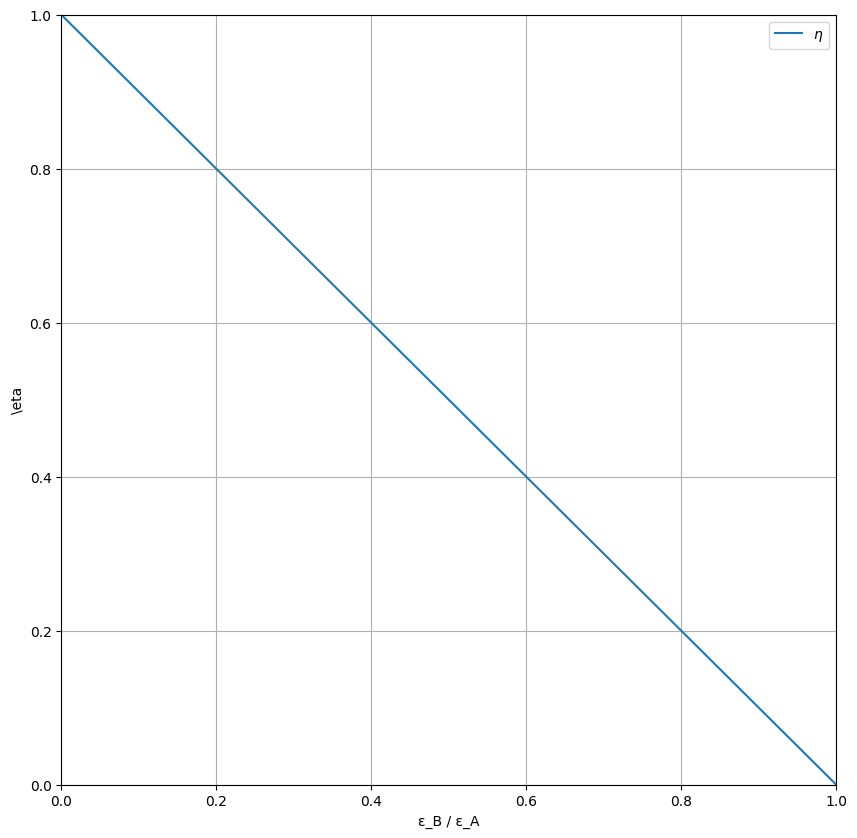

In [13]:
#gerando matrizes
ener=np.linspace(0,1,101)
beta=np.linspace(1,4,101)

X,Y=np.meshgrid(ener,beta)#mesh

for fig,i in enumerate(range(4,5,2)):
  #gerando as matrizes
  eta_mean=np.zeros((len(ener)),dtype=complex)
  box1=cnots_n(i)
  box2=boxs_par_swap(i)
  #gerando o estado inicial
  trace_ind=np.linspace(1,i-2,i-2,dtype=int)
  trace_ind_q=np.linspace(1,int((i-2)/2),int((i-2)/2),dtype=int)
  dimension=cnot(i,0,1).dims
  rho0_f=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
  b=2
  for j,e in enumerate(ener):

    #gerando estado inicial
    rho0=rho0_f

    # gerando estado
    theta_a,theta_b,x=thetas_c(e,b)


    rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

    #calculando rho final
    rho0=rho_therma_corr1*rho_therma_corr1.dag()
    rho_therma_corr1=box2*rho_therma_corr1
    rhof=rho_therma_corr1*rho_therma_corr1.dag()

    #calculo do trabalho
    qa=-(((ptrace(rhof,trace_ind_q)-ptrace(rho0,trace_ind_q))*hamiltoniana_a(e,1,i)).tr())
    w=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())
    eta_mean[j]=-(w/qa).real
  #plotando o gráfico
  plt.figure(figsize=(10, 10))
  #plt.title(f"$\\eta$ n_qubits={i-2}")
  plt.xlim(0,1)
  plt.ylim(0,1)
  plt.plot(ener,eta_mean,label='$\\eta$')
  plt.legend()
  plt.grid()
  plt.xlabel('ε_B / ε_A')
  plt.ylabel('\\eta')
  plt.show()

# W_c/W_u

Aqui iremos trabalhar onde efiência é acima do carnot

Nesse caso é 0<eb/ea<0.5

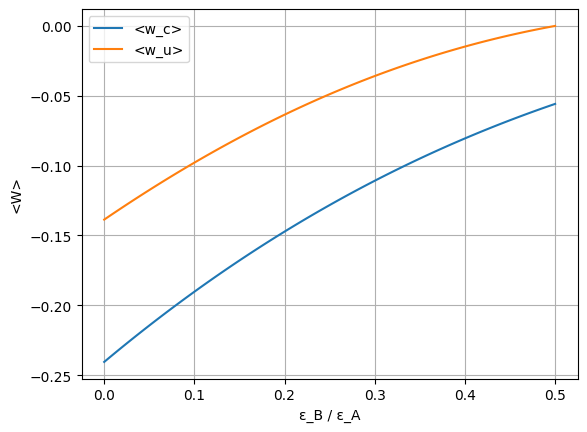

In [14]:
def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A*0.5))

  Zb = np.trace(expm(-bb * H_B*0.5))
  #operador densidade

  p_a=np.exp(-ba*ea*0.5)/Za
  p_b=np.exp(-bb*eb*0.5)/Zb
  #coeficiente

  a=1/(Za*Zb)**1.5

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=((p_b-p_a)/(pp-pm)+1)*0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x

b=2
i=4
box1=cnots_n(i)
box2=boxs_par_swap(i)

dimension=cnot(i,0,1).dims
rho0_f=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
trace_ind=np.linspace(1,i-2,i-2,dtype=int)
w1=np.zeros(101,dtype=complex)
w2=np.zeros(101,dtype=complex)
ener=np.linspace(0,0.5,101)

for j,e in enumerate(ener):

  rho0=rho0_f
  theta_a,theta_b,x=thetas_c(e,b)

  rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

  #calculando rho final
  rho0=rho_therma_corr1*rho_therma_corr1.dag()
  rho_therma_corr1=box2*rho_therma_corr1
  rhof=rho_therma_corr1*rho_therma_corr1.dag()

  #calculo do trabalho
  w1[j]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())


  rho0=rho0_f
  theta_a,theta_b,x=thetas_u(e,b)

  rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

  #calculando rho final
  rho0=rho_therma_corr1*rho_therma_corr1.dag()
  rho_therma_corr1=box2*rho_therma_corr1
  rhof=rho_therma_corr1*rho_therma_corr1.dag()

  #calculo do trabalho
  w2[j]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())

plt.plot(ener,w1,label='<w_c>')
plt.plot(ener,w2,label='<w_u>')
plt.legend()
plt.grid()
plt.xlabel('ε_B / ε_A')
plt.ylabel('<W>')
plt.show()

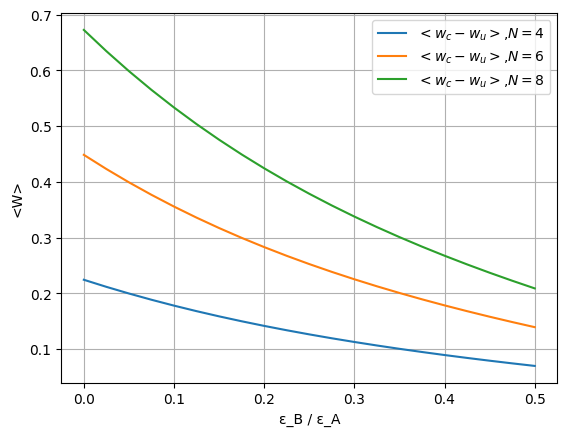

In [7]:
def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb
  #coeficiente

  a=1/(Za*Zb)**1.2

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=((p_b-p_a)/(pp-pm)+1)*0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x

b=2
for fig,i in enumerate(range(4,9,2)):

  box1=cnots_n(i)
  box2=boxs_par_swap(i)

  dimension=cnot(i,0,1).dims
  rho0_f=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
  trace_ind=np.linspace(1,i-2,i-2,dtype=int)
  ener=np.linspace(0,0.5,21)
  w1=np.zeros(len(ener),dtype=complex)
  w2=np.zeros(len(ener),dtype=complex)

  for j,e in enumerate(ener):
    #estado inicial
    rho0=rho0_f

    theta_a,theta_b,x=thetas_c(e,b)

    rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

    #calculando rho final
    rho0=rho_therma_corr1*rho_therma_corr1.dag()
    rho_therma_corr1=box2*rho_therma_corr1
    rhof=rho_therma_corr1*rho_therma_corr1.dag()

    #calculo do trabalho
    w1[j]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())


    rho0=rho0_f
    theta_a,theta_b,x=thetas_u(e,b)

    rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

    #calculando rho final
    rho0=rho_therma_corr1*rho_therma_corr1.dag()
    rho_therma_corr1=box2*rho_therma_corr1
    rhof=rho_therma_corr1*rho_therma_corr1.dag()

    #calculo do trabalho
    w2[j]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())
  plt.plot(ener,abs(w1-w2),label=f'$|<w_c-w_u>|$,$N=${i}')
plt.legend()
plt.grid()
plt.xlabel('ε_B / ε_A')
plt.ylabel('<W>')
plt.show()

In [ ]:
def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb
  #coeficiente

  a=1/(Za*Zb)**1.2

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=((p_b-p_a)/(pp-pm)+1)*0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x

b=2
e=0.1

num=[4,6,8,10,12,14]

w1=np.zeros(len(num),dtype=complex)
w2=np.zeros(len(num),dtype=complex)
for fig,i in enumerate(num):

  box1=cnots_n(i)
  box2=boxs_par_swap(i)

  dimension=cnot(i,0,1).dims
  rho0_f=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
  trace_ind=np.linspace(1,i-2,i-2,dtype=int)

  #estado inicial
  rho0=rho0_f

  theta_a,theta_b,x=thetas_c(e,b)

  rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

  #calculando rho final
  rho0=rho_therma_corr1*rho_therma_corr1.dag()
  rho_therma_corr1=box2*rho_therma_corr1
  rhof=rho_therma_corr1*rho_therma_corr1.dag()

  #calculo do trabalho
  w1[fig]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())


  rho0=rho0_f
  theta_a,theta_b,x=thetas_u(e,b)

  rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

  #calculando rho final
  rho0=rho_therma_corr1*rho_therma_corr1.dag()
  rho_therma_corr1=box2*rho_therma_corr1
  rhof=rho_therma_corr1*rho_therma_corr1.dag()

  #calculo do trabalho
  w2[fig]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())

plt.plot(num,abs(w1-w2),label=f'<|w_c-w_u|>$N_q$')
plt.legend()
plt.grid()
plt.xlabel('N')
plt.ylabel('<W>')
plt.show()

# Penny Lane

In [ ]:
pip install pennylane --upgrade

In [ ]:
import pennylane as qml
from pennylane import numpy as np

def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  ea=1
  ba=1
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb

  #coeficiente

  a=1/(Za*Zb)**1.5

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=abs(p_b-p_a)/(pp-pm)*0.5+0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pm))
  theta_b=2*np.arccos(np.sqrt(pp))

  return theta_a,theta_b,x

dev2 = qml.device("default.qubit", wires=4)
dev1 = qml.device("default.qubit", wires=4,shots=10000)

def u_plus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_plus = term1 + term2
    return np.array((u_plus).full())
def u_minus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return np.array((u_minus).full())

def box_ther_cor(theta_A, theta_B,x,e):
    #termico
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=3)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[3, 2])
    #correlação
    qml.CNOT(wires=[0, 3])
    qml.ControlledQubitUnitary(u_minus1(x), control_wires=[3], wires=[0])
    qml.CNOT(wires=[0, 3])
    qml.CNOT(wires=[1, 2])
    qml.ControlledQubitUnitary(u_minus1(x), control_wires=[2], wires=[1])
    qml.CNOT(wires=[1, 2])

@qml.qnode(dev1)
def probss(theta_A, theta_B,x,e):
  box_ther_cor(theta_A, theta_B,x,e)
  return qml.expval(-e*qml.PauliZ(1)*0.5-qml.PauliZ(2)*0.5)

def box_4(theta_A,theta_B,x,e):
    #termico
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=3)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[3, 2])
    #correlação
    qml.CNOT(wires=[0, 3])
    qml.ControlledQubitUnitary(u_minus1(x), control_wires=[3], wires=[0])
    qml.CNOT(wires=[0, 3])
    qml.CNOT(wires=[1, 2])
    qml.ControlledQubitUnitary(u_minus1(x), control_wires=[2], wires=[1])
    qml.CNOT(wires=[1, 2])
    #trabalho
    qml.CNOT(wires=[1, 2])
    qml.ControlledQubitUnitary(u_plus1(x), control_wires=[2], wires=[1])
    qml.CNOT(wires=[1, 2])
    #return qml.expval(e*qml.PauliZ(1)+qml.PauliZ(2))

@qml.qnode(dev1)
def probss2(theta_A,theta_B,x,e):
    box_4(theta_A, theta_B,x,e)
    return qml.expval(-e*qml.PauliZ(1)*0.5-qml.PauliZ(2)*0.5)

# Example usage
ener=np.linspace(0,0.5,51)
b=2
W_exp=np.zeros(51)
for j,e in enumerate(ener):
  theta_A,theta_B,x=thetas_c(e,2)

  exp_value = probss(theta_A, theta_B,x,e)
  exp_value2= probss2(theta_A, theta_B,x,e)
  W_exp[j]=exp_value2-exp_value

plt.plot(ener,W_exp,'.',label='<w_c>_sample')

ener=np.linspace(0,0.5,101)

plt.plot(ener,w1,label='<w_c>')

plt.legend()
plt.grid()
plt.xlabel('ε_B / ε_A')
plt.ylabel('<W>')
plt.show()